## Large Dataset of Cars

- This dataset provides a comprehensive overview of various vehicles and their key technical specifications. It includes detailed attributes such as brand,  vehicle class, region of origin, engine size, horsepower, and fuel efficiency. Both MSRP and dealer cost are included, enabling analysis of pricing strategies and market positioning. With engine characteristics like horsepower, kagglers can explore performance comparisons between different car segments. The dataset also includes physical dimensions such as weight, wheelbase, and total length, useful for engineering or analysis. It is well-suited for building predictive models to estimate car prices or fuel consumption. Kagglers can use it to identify correlations between technical specifications and pricing. It is also valuable for clustering similar vehicles or segmenting the market based on car class and region. Whether you're passionate about cars, machine learning, or market analytics, this dataset offers a rich ground for experimentation. Ideal for projects in regression, classification, or data visualization.


## Columns:

- Brand – car brand
- VehicleClass – body type
- Region – geographical region where the car was manufactured
- MSRP – manufacturer’s suggested retail price
- DealerCost – the price at which the car is sold by the dealer
- EngineSize – size of the engine in liters
- HorsePower – maximum engine power output in horsepower
- MPG_City – fuel economy in miles per gallon while driving in city conditions
- MPG_Highway – fuel economy in miles per gallon while driving on highways
- Weight – weight of the vehicle in pounds
- Wheelbase – distance between the front and rear wheels
- Length – total length of the vehicle from bumper to bumper

In [133]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandasql as psql

In [135]:
df = pd.read_excel("Large Cars Dataset.xlsx")

In [137]:
df

,Brand,VehicleClass,Region,MSRP,DealerCost,EngineSize,HorsePower,MPG_City,MPG_Highway,Weight,Wheelbase,Length
0,Acura,SUV,Asia,36945,33337,3.5,265,17,23,4451,106,189
1,Acura,Sedan,Asia,23820,21761,2.0,200,24,31,2778,101,172
2,Acura,Sedan,Asia,26990,24647,2.4,200,22,29,3230,105,183
3,Acura,Sedan,Asia,33195,30299,3.2,270,20,28,3575,108,186
4,Acura,Sedan,Asia,43755,39014,3.5,225,18,24,3880,115,197
...,...,...,...,...,...,...,...,...,...,...,...,...
423,Volvo,Sedan,Europe,40565,38203,2.4,197,21,28,3450,105,186
424,Volvo,Sedan,Europe,42565,40083,2.3,242,20,26,3450,105,186
425,Volvo,Sedan,Europe,45210,42573,2.9,268,19,26,3653,110,190
426,Volvo,Wagon,Europe,26135,24641,1.9,170,22,29,2822,101,180


In [139]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 428 entries, 0 to 427
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Brand         428 non-null    object 
 1   VehicleClass  428 non-null    object 
 2   Region        428 non-null    object 
 3   MSRP          428 non-null    int64  
 4   DealerCost    428 non-null    int64  
 5   EngineSize    428 non-null    float64
 6   HorsePower    428 non-null    int64  
 7   MPG_City      428 non-null    int64  
 8   MPG_Highway   428 non-null    int64  
 9   Weight        428 non-null    int64  
 10  Wheelbase     428 non-null    int64  
 11  Length        428 non-null    int64  
dtypes: float64(1), int64(8), object(3)
memory usage: 40.3+ KB


## Goals:

- Which brand is the most valuable?
- What is the most valuable vehicle class?
- Which region that makes the most valuable vehicles?
- What vehicle class is the most fuel-efficient?
- What is the lightest vehicle class?
- Which vehicle class that has the best performance?
- What factors that contributes to a vehicle's value?

In [143]:
df['Value'] = df['MSRP'] - df['DealerCost'] # Suggested retail price - dealer's cost

In [145]:
df

,Brand,VehicleClass,Region,MSRP,DealerCost,EngineSize,HorsePower,MPG_City,MPG_Highway,Weight,Wheelbase,Length,Value
0,Acura,SUV,Asia,36945,33337,3.5,265,17,23,4451,106,189,3608
1,Acura,Sedan,Asia,23820,21761,2.0,200,24,31,2778,101,172,2059
2,Acura,Sedan,Asia,26990,24647,2.4,200,22,29,3230,105,183,2343
3,Acura,Sedan,Asia,33195,30299,3.2,270,20,28,3575,108,186,2896
4,Acura,Sedan,Asia,43755,39014,3.5,225,18,24,3880,115,197,4741
...,...,...,...,...,...,...,...,...,...,...,...,...,...
423,Volvo,Sedan,Europe,40565,38203,2.4,197,21,28,3450,105,186,2362
424,Volvo,Sedan,Europe,42565,40083,2.3,242,20,26,3450,105,186,2482
425,Volvo,Sedan,Europe,45210,42573,2.9,268,19,26,3653,110,190,2637
426,Volvo,Wagon,Europe,26135,24641,1.9,170,22,29,2822,101,180,1494


## Goal 1: Which brand is the most valuable?

## 1)Market value of brand

In [149]:
query1 = """SELECT Brand, SUM(Value) as Value FROM df 
GROUP BY Brand"""

In [150]:
Brand = psql.sqldf(query1)

In [151]:
Brand

,Brand,Value
0,Acura,30434
1,Audi,75578
2,BMW,73292
3,Buick,24146
4,Cadillac,32380
5,Chevrolet,68208
6,Chrysler,29729
7,Dodge,27219
8,Ford,47446
9,GMC,26169


In [152]:
Brand_sort = Brand.sort_values(by = 'Value', ascending = False)

In [154]:
Brand_sort

,Brand,Value
23,Mercedes-Benz,109291
1,Audi,75578
2,BMW,73292
29,Porsche,69315
5,Chevrolet,68208
15,Jaguar,65784
35,Toyota,62399
19,Lexus,60010
8,Ford,47446
36,Volkswagen,38490


## 2)Value of brand

In [158]:
query2 = """SELECT Brand, AVG(Value) as Value FROM df 
GROUP BY Brand"""

In [160]:
Brand_value = psql.sqldf(query2)

In [161]:
Brand_value

,Brand,Value
0,Acura,4347.714286
1,Audi,3977.789474
2,BMW,3664.600000
3,Buick,2682.888889
4,Cadillac,4047.500000
5,Chevrolet,2526.222222
6,Chrysler,1981.933333
7,Dodge,2093.769231
8,Ford,2062.869565
9,GMC,3271.125000


In [163]:
Brand_value_sort = Brand_value.sort_values(by = 'Value', ascending = False)

In [164]:
Brand_value_sort

,Brand,Value
29,Porsche,9902.142857
15,Jaguar,5482.000000
19,Lexus,5455.454545
0,Acura,4347.714286
23,Mercedes-Benz,4203.500000
11,Hummer,4180.000000
4,Cadillac,4047.500000
18,Land Rover,3980.666667
1,Audi,3977.789474
20,Lincoln,3739.777778


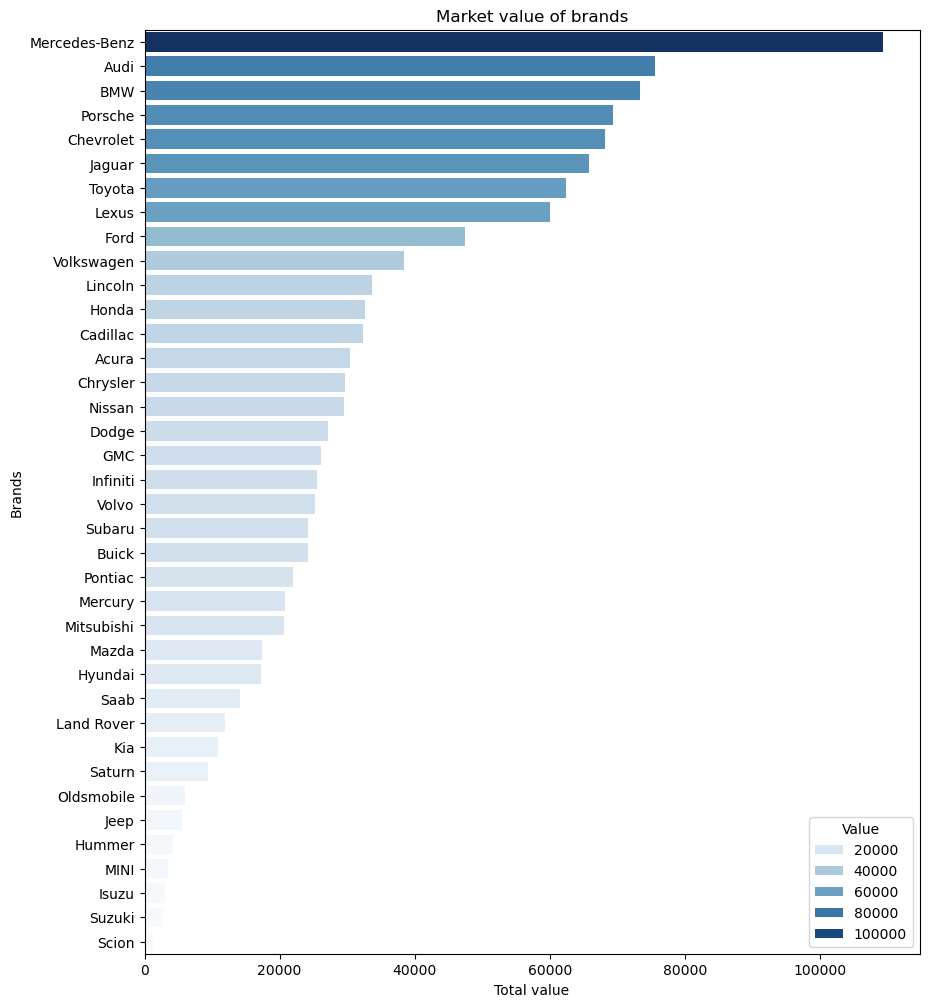

In [166]:
plt.figure(figsize= (10, 12))
sns.barplot(data = Brand_sort, y = Brand_sort['Brand'], x = Brand_sort['Value'], palette = 'Blues', hue = Brand_sort['Value'])
plt.xlabel('Total value')
plt.ylabel('Brands')
plt.title('Market value of brands')
plt.show()

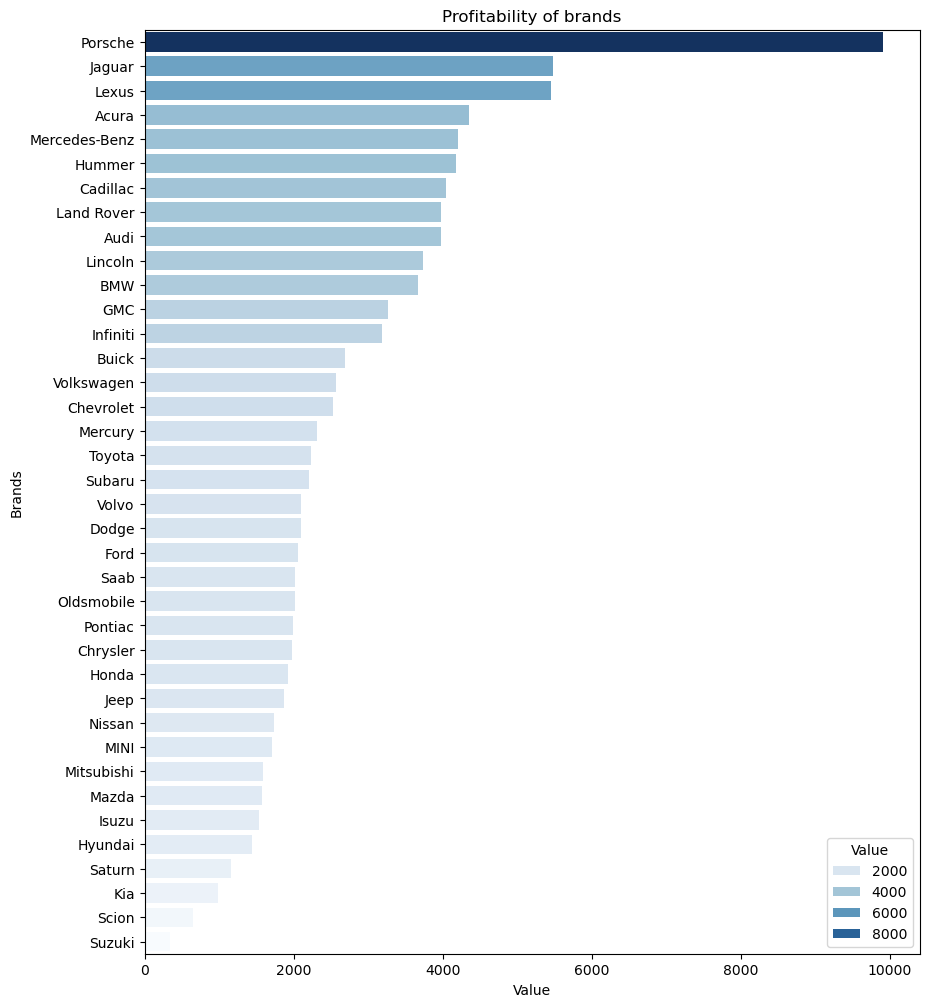

In [167]:
plt.figure(figsize= (10, 12))
sns.barplot(data = Brand_value_sort, y = Brand_value_sort['Brand'], x = Brand_value_sort['Value'], palette = 'Blues', 
            hue = Brand_value_sort['Value'])
plt.xlabel('Value')
plt.ylabel('Brands')
plt.title('Profitability of brands')
plt.show()

## Conclusions:
- Mercedes-Benz, Audi, BMW, Porsche, Chevrolet, Jaguar, Toyota, Lexus and Ford are the brands with the highest market values.
- In contrast, Porsche has the highest brand recognition, followed by Jaguar and Lexus, meaning they make the most luxurious and valuable vehicles.

# Case studies:
## Porsche: 
- Known for its quality performance and valuable heritage, Same thing for both Jaguar and Lexus.
## Toyota:
- Toyota makes profits from selling economic cars than luxurious cars, it's not a luxury brand like Porsche.
## Hummer:
1) It has weak market value due to its struggle with practicality in every day activities, rising fuel prices and environmental criticism.
2) But has high brand recognition due to it being the first vehicle brand to make SUVS (Sport utility vehicles) and being marketed by different celebirties like Arnold Schwarzenegger.
## Ford:
- which is known for being one of the first vehicle brands to make cars affordable for everyone due to mass production, has suffered immense problems which weakened its brand recognition: Its focus on quantity over quality, its dependency on fuel which was skyrocketed after the 2008 financial crisis and the whole world decided to look for different energy sources to use in manufacturing of cars, Same thing for chervolet.
## Suzuki:
- Has the weakest market value and brand recognition, it focuses on the Japanese market and few other markets like the middle east.

## Goal 2: What is the most valuable vehicle class?

In [173]:
df

,Brand,VehicleClass,Region,MSRP,DealerCost,EngineSize,HorsePower,MPG_City,MPG_Highway,Weight,Wheelbase,Length,Value
0,Acura,SUV,Asia,36945,33337,3.5,265,17,23,4451,106,189,3608
1,Acura,Sedan,Asia,23820,21761,2.0,200,24,31,2778,101,172,2059
2,Acura,Sedan,Asia,26990,24647,2.4,200,22,29,3230,105,183,2343
3,Acura,Sedan,Asia,33195,30299,3.2,270,20,28,3575,108,186,2896
4,Acura,Sedan,Asia,43755,39014,3.5,225,18,24,3880,115,197,4741
...,...,...,...,...,...,...,...,...,...,...,...,...,...
423,Volvo,Sedan,Europe,40565,38203,2.4,197,21,28,3450,105,186,2362
424,Volvo,Sedan,Europe,42565,40083,2.3,242,20,26,3450,105,186,2482
425,Volvo,Sedan,Europe,45210,42573,2.9,268,19,26,3653,110,190,2637
426,Volvo,Wagon,Europe,26135,24641,1.9,170,22,29,2822,101,180,1494


## 1) Market value of class

In [176]:
Total_class = df.groupby('VehicleClass')['Value'].sum().reset_index()

In [178]:
Total_class

,VehicleClass,Value
0,Hybrid,4472
1,SUV,189894
2,Sedan,624561
3,Sports,240781
4,Truck,55791
5,Wagon,65847


In [180]:
Total_class_sort = Total_class.sort_values(by = 'Value', ascending = False)

In [181]:
Total_class_sort

,VehicleClass,Value
2,Sedan,624561
3,Sports,240781
1,SUV,189894
5,Wagon,65847
4,Truck,55791
0,Hybrid,4472


## 2) Class by profitability

In [184]:
Avg_class = df.groupby('VehicleClass')['Value'].mean().reset_index()

In [186]:
Avg_class

,VehicleClass,Value
0,Hybrid,1490.666667
1,SUV,3164.900000
2,Sedan,2383.820611
3,Sports,4913.897959
4,Truck,2324.625000
5,Wagon,2194.900000


In [191]:
Avg_class_sort = Avg_class.sort_values(by = 'Value', ascending = False)

In [195]:
Avg_class_sort

,VehicleClass,Value
3,Sports,4913.897959
1,SUV,3164.900000
2,Sedan,2383.820611
4,Truck,2324.625000
5,Wagon,2194.900000
0,Hybrid,1490.666667


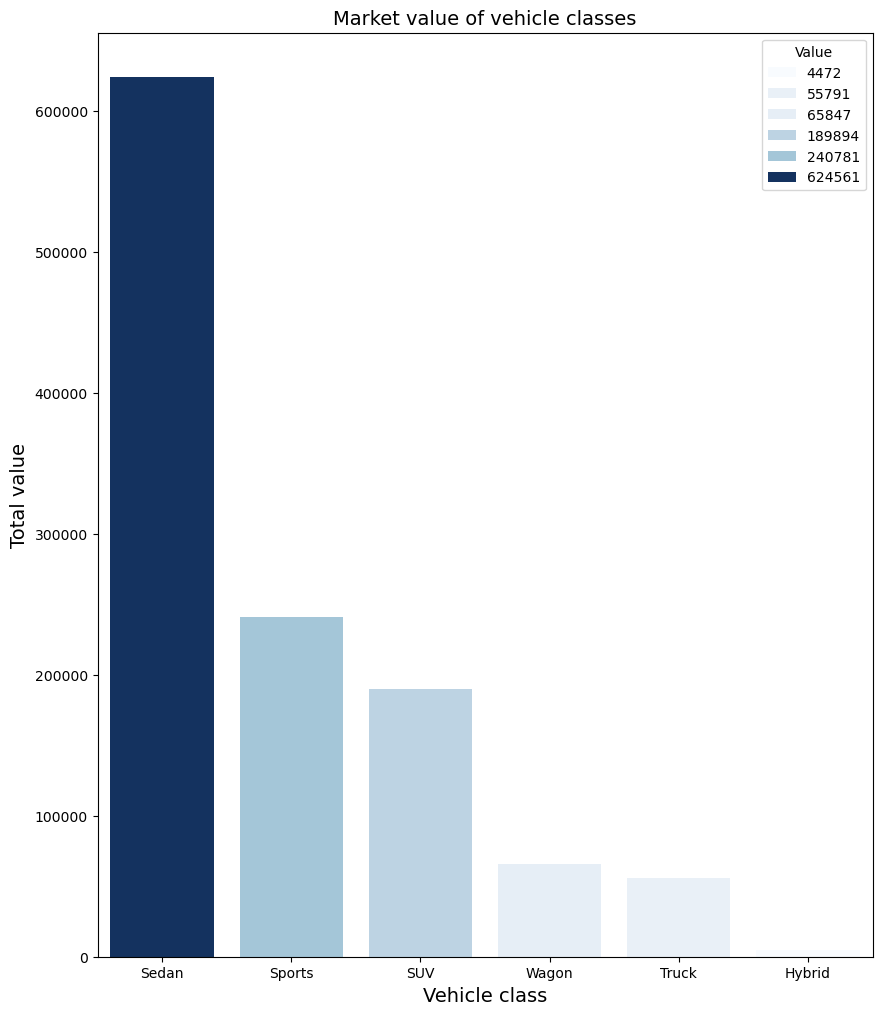

In [197]:
plt.figure(figsize= (10, 12))
sns.barplot(data = Total_class_sort, x = Total_class_sort['VehicleClass'], y = Total_class_sort['Value'], palette = 'Blues', hue = Total_class_sort['Value'])
plt.xlabel('Vehicle class', size = 14)
plt.ylabel('Total value', size = 14)
plt.title('Market value of vehicle classes', size = 14)
plt.show()

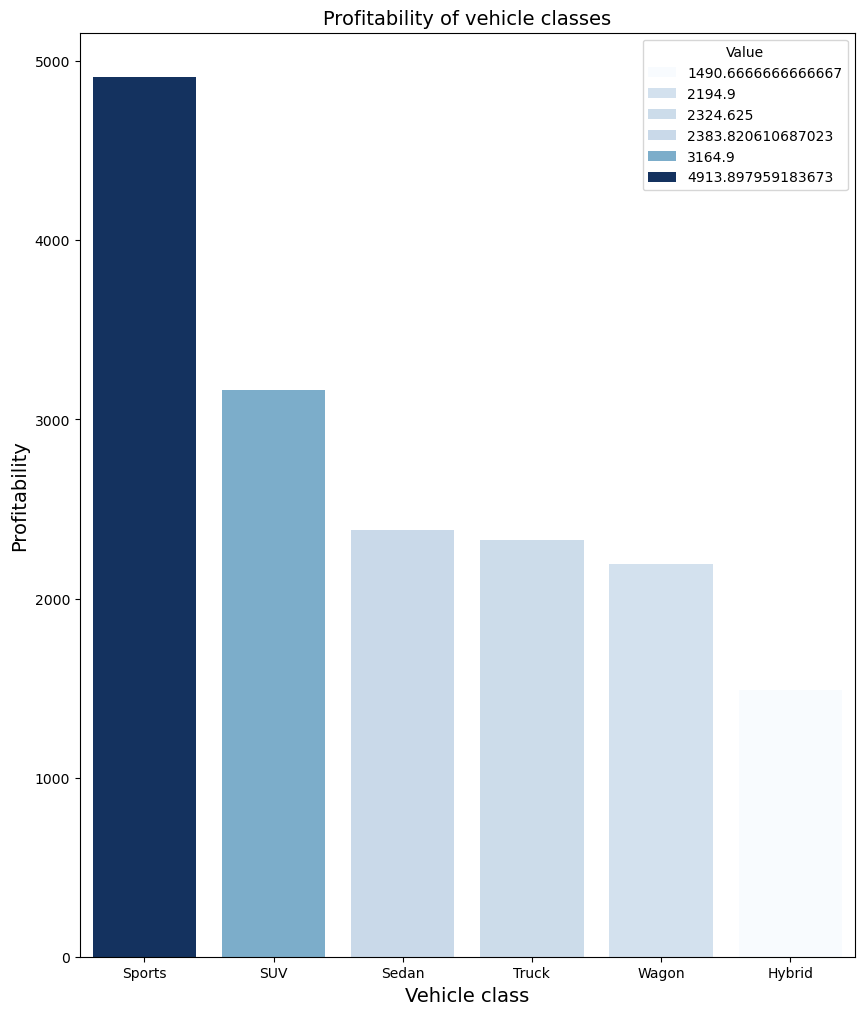

In [198]:
plt.figure(figsize= (10, 12))
sns.barplot(data = Avg_class_sort, x = Avg_class_sort['VehicleClass'], y = Avg_class_sort['Value'], palette = 'Blues', hue = Avg_class_sort['Value'])
plt.xlabel('Vehicle class', size = 14)
plt.ylabel('Profitability', size = 14)
plt.title('Profitability of vehicle classes', size = 14)
plt.show()

## Conclusions:
- Sedan vehicle class has the most market value due to the abundance of vehicles that belong to this class.
- But it's the least profitable.
- In contrast, Sports vehicle class is the most profitable, this class promotes luxury, brand awarness, impression and prestige.
- But it's less abundant due to its limited supply, which increases its demand and therefore its value.
- SUV vehicle class is profitable, it offers both luxury and practicality, they cater to everyday needs: from travels to work to comfort.
- But like sports vehicle class, it's less abundent.
- Truck, Wagon and Hybrid vehicle classes are the least abundant and the least profitable.
- This is due to them being function based rather than variety based.

## Goal 3: Which region that makes the most valuable vehicles?

In [203]:
df

,Brand,VehicleClass,Region,MSRP,DealerCost,EngineSize,HorsePower,MPG_City,MPG_Highway,Weight,Wheelbase,Length,Value
0,Acura,SUV,Asia,36945,33337,3.5,265,17,23,4451,106,189,3608
1,Acura,Sedan,Asia,23820,21761,2.0,200,24,31,2778,101,172,2059
2,Acura,Sedan,Asia,26990,24647,2.4,200,22,29,3230,105,183,2343
3,Acura,Sedan,Asia,33195,30299,3.2,270,20,28,3575,108,186,2896
4,Acura,Sedan,Asia,43755,39014,3.5,225,18,24,3880,115,197,4741
...,...,...,...,...,...,...,...,...,...,...,...,...,...
423,Volvo,Sedan,Europe,40565,38203,2.4,197,21,28,3450,105,186,2362
424,Volvo,Sedan,Europe,42565,40083,2.3,242,20,26,3450,105,186,2482
425,Volvo,Sedan,Europe,45210,42573,2.9,268,19,26,3653,110,190,2637
426,Volvo,Wagon,Europe,26135,24641,1.9,170,22,29,2822,101,180,1494


## 1)Market value

In [206]:
Region = df.groupby('Region')['Value'].sum().reset_index()

In [208]:
Region

,Region,Value
0,Asia,337985
1,Europe,486430
2,USA,356931


In [210]:
Region_sort = Region.sort_values(by = 'Value', ascending = False)

In [212]:
Region_sort

,Region,Value
1,Europe,486430
2,USA,356931
0,Asia,337985


## 2)Profitability

In [215]:
Region_profit = df.groupby('Region')['Value'].mean().reset_index()

In [217]:
Region_profit

,Region,Value
0,Asia,2139.145570
1,Europe,3954.715447
2,USA,2428.102041


In [219]:
Region_profit_sort = Region_profit.sort_values(by = 'Value', ascending = False )

In [221]:
Region_profit_sort

,Region,Value
1,Europe,3954.715447
2,USA,2428.102041
0,Asia,2139.145570


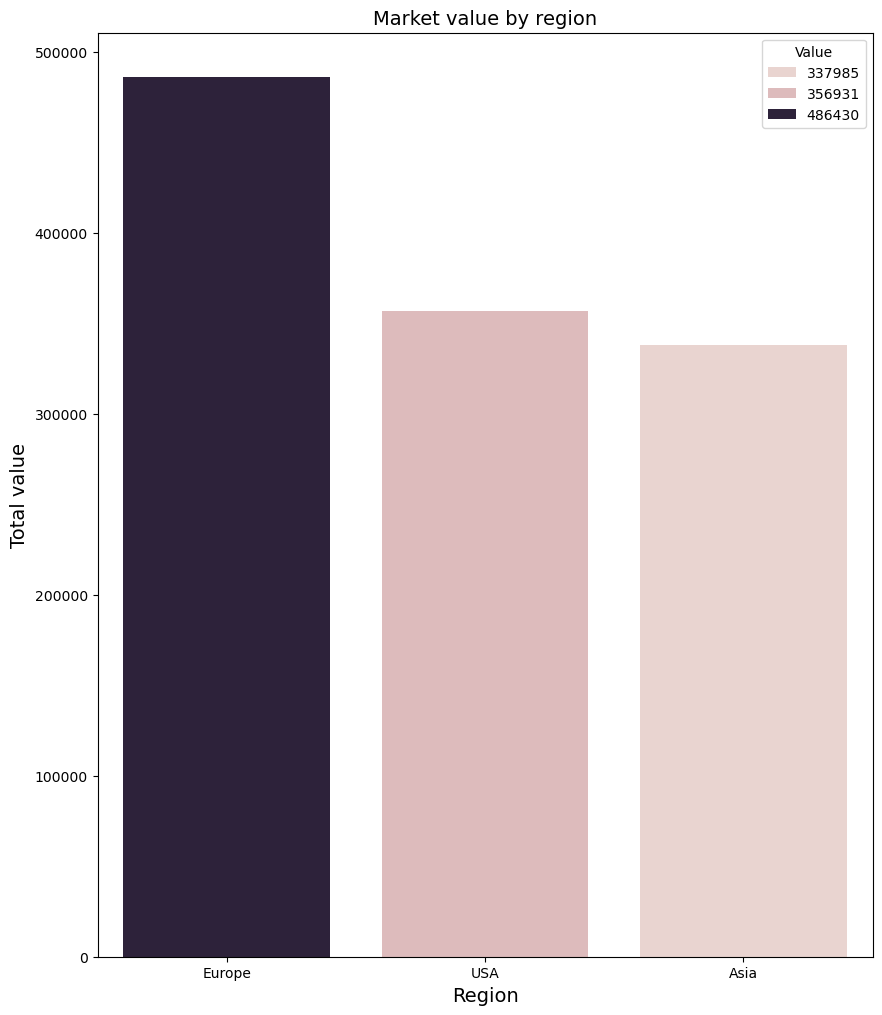

In [223]:
plt.figure(figsize= (10, 12))
sns.barplot(data = Region_sort, x = Region_sort['Region'], y = Region_sort['Value'], hue = Region_sort['Value'])
plt.xlabel('Region', size = 14)
plt.ylabel('Total value', size = 14)
plt.title('Market value by region', size = 14)
plt.show()

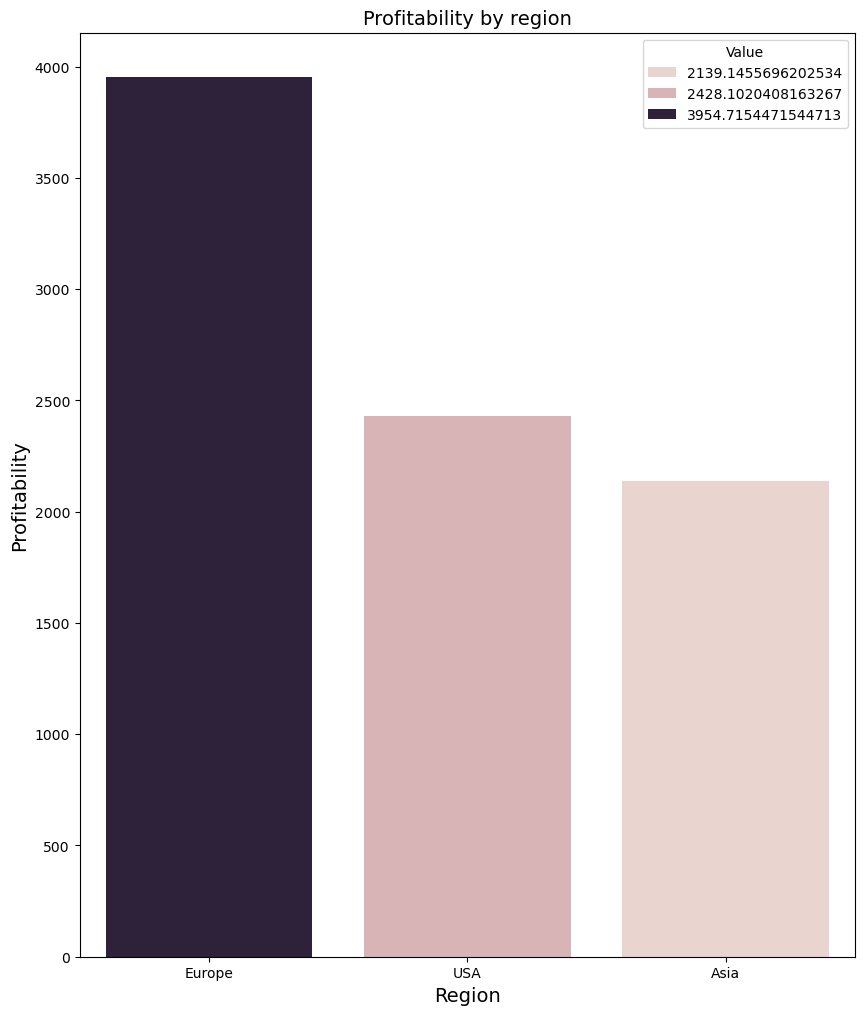

In [225]:
plt.figure(figsize= (10, 12))
sns.barplot(data = Region_profit_sort, x = Region_profit_sort['Region'], y = Region_profit_sort['Value'],  hue = Region_profit_sort['Value'])
plt.xlabel('Region', size = 14)
plt.ylabel('Profitability', size = 14)
plt.title('Profitability by region', size = 14)
plt.show()

## Conclusions:
- From the two bar charts: The data values are common

## Europe: 
- Europe has both the highest market value and profitability. 
- This is due to the EU(European union) which is one of the biggest economic unions around the world.
- It was established in 1993, two years after the cold war.
- This union follows principles of cooperation between countries and trade between nations.
- This region has world wide and house hold vehicle brand names like:-
1) Porsche
2) BMW
3) Jaguar
4) Aston Martin
5) Ferrari
6) Audi
7) Mercedes Benz
8) Lamborghini
9) Land Rover
10) Fiat 

## USA:
- After Europe, USA has both high market value and profitability.
- This is due to it being one of the biggest countries in the world, with one of the biggest economies.
- This country has world wide and house hold vehicle brand names like:-
1) Ford
2) General motors
3) Chervolet
4) Tesla
5) Dodge
6) Hummer
7) Chrysler 

## Asia:
- This region has less market value and profitability than Europe and the USA.
- Although Japan, China, South Korea, Singapore, Malaysia and Indonesia have strong economies, there's no economic unity between them like the EU and the USA.
- However, this region is home to world and house hold vehicle brand names like:
1) Toyota
2) Mitsubishi
3) BYD
4) Honda
5) Hyundai
- This region has potential, especially with the rising demand of vehicles powered with non-fuel energy sources, which is what China is planning to do.

## Goal 4: What vehicle class is the most fuel-efficient?

In [232]:
df

,Brand,VehicleClass,Region,MSRP,DealerCost,EngineSize,HorsePower,MPG_City,MPG_Highway,Weight,Wheelbase,Length,Value
0,Acura,SUV,Asia,36945,33337,3.5,265,17,23,4451,106,189,3608
1,Acura,Sedan,Asia,23820,21761,2.0,200,24,31,2778,101,172,2059
2,Acura,Sedan,Asia,26990,24647,2.4,200,22,29,3230,105,183,2343
3,Acura,Sedan,Asia,33195,30299,3.2,270,20,28,3575,108,186,2896
4,Acura,Sedan,Asia,43755,39014,3.5,225,18,24,3880,115,197,4741
...,...,...,...,...,...,...,...,...,...,...,...,...,...
423,Volvo,Sedan,Europe,40565,38203,2.4,197,21,28,3450,105,186,2362
424,Volvo,Sedan,Europe,42565,40083,2.3,242,20,26,3450,105,186,2482
425,Volvo,Sedan,Europe,45210,42573,2.9,268,19,26,3653,110,190,2637
426,Volvo,Wagon,Europe,26135,24641,1.9,170,22,29,2822,101,180,1494


## 1) Total MPG (miles per gallon)

In [235]:
MPG_sum = df.groupby('VehicleClass')[['MPG_City', 'MPG_Highway']].sum().reset_index()

In [237]:
MPG_sum

,VehicleClass,MPG_City,MPG_Highway
0,Hybrid,165,168
1,SUV,966,1230
2,Sedan,5524,7501
3,Sports,902,1249
4,Truck,396,504
5,Wagon,633,837


In [239]:
MPG_sum_sort = MPG_sum.sort_values(by = ['MPG_City', 'MPG_Highway'], ascending = False)

In [241]:
MPG_sum_sort

,VehicleClass,MPG_City,MPG_Highway
2,Sedan,5524,7501
1,SUV,966,1230
3,Sports,902,1249
5,Wagon,633,837
4,Truck,396,504
0,Hybrid,165,168


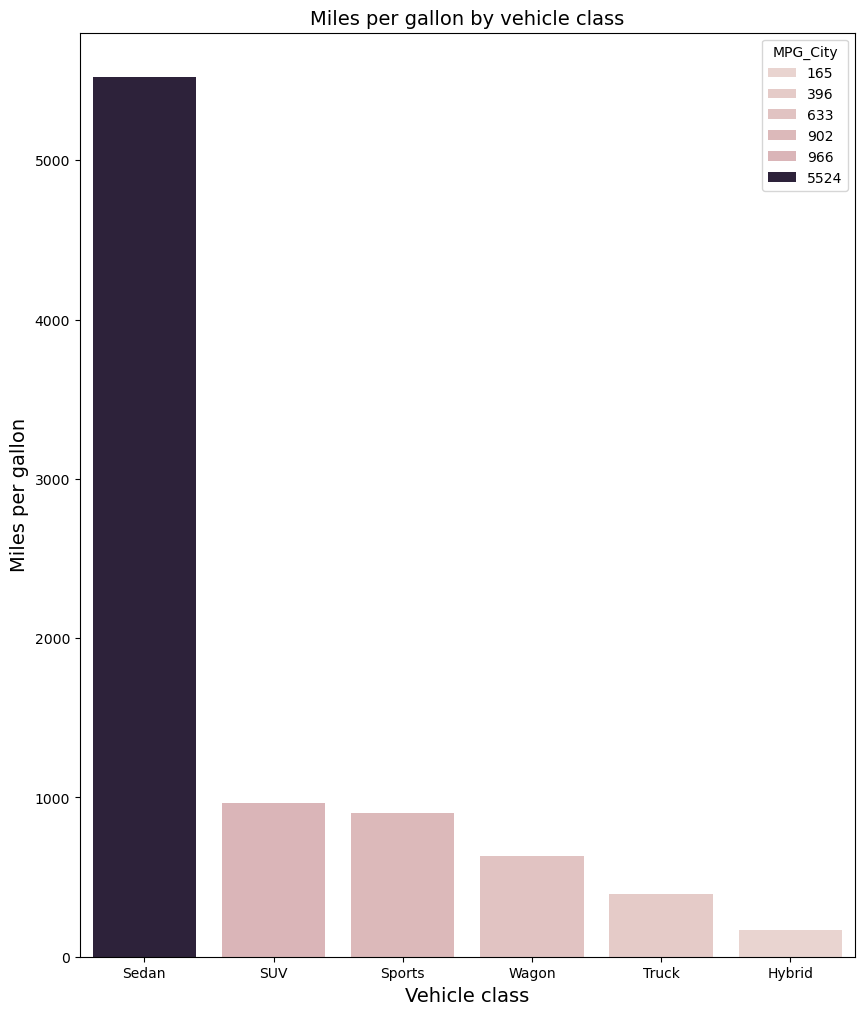

In [251]:
plt.figure(figsize= (10, 12))
sns.barplot(data = MPG_sum_sort, x = MPG_sum_sort['VehicleClass'], y = MPG_sum_sort['MPG_City'],  hue = MPG_sum_sort['MPG_City'])
plt.xlabel('Vehicle class', size = 14)
plt.ylabel('Miles per gallon', size = 14)
plt.title('Miles per gallon by vehicle class', size = 14)
plt.show()

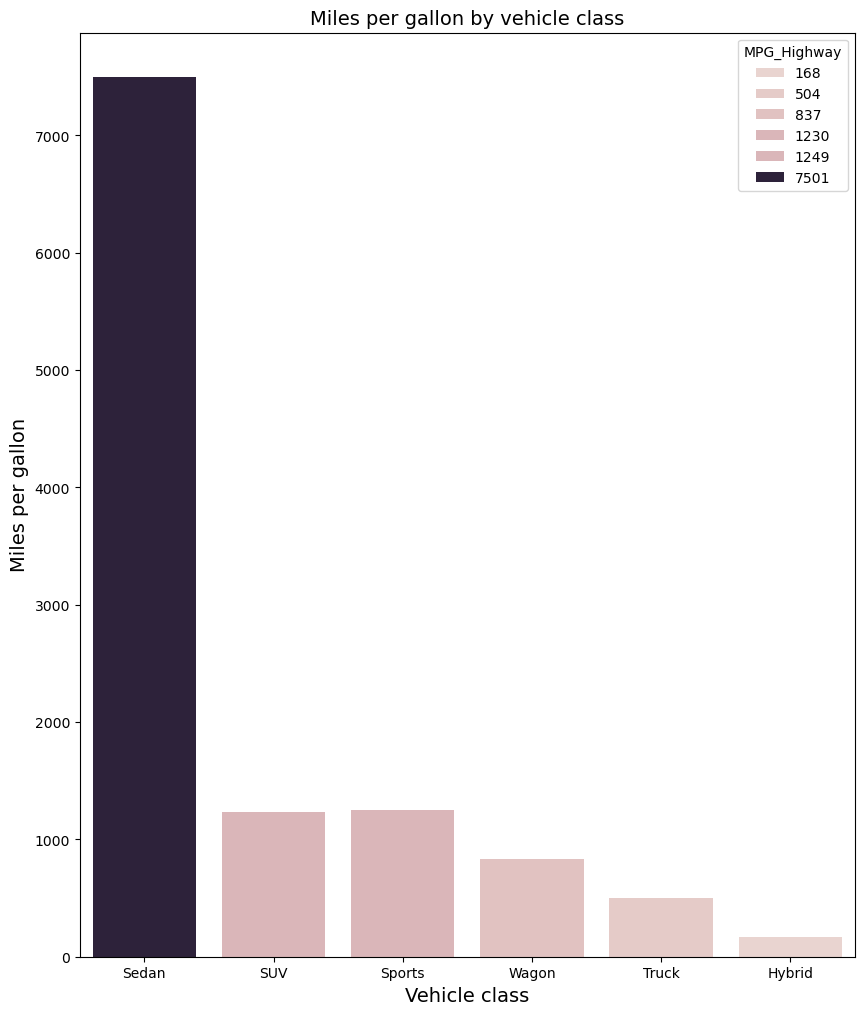

In [253]:
plt.figure(figsize= (10, 12))
sns.barplot(data = MPG_sum_sort, x = MPG_sum_sort['VehicleClass'], y = MPG_sum_sort['MPG_Highway'],  hue = MPG_sum_sort['MPG_Highway'])
plt.xlabel('Vehicle class', size = 14)
plt.ylabel('Miles per gallon', size = 14)
plt.title('Miles per gallon by vehicle class', size = 14)
plt.show()

## Conclusions:
- Sedans consume the most fuel out of vehicle classes, due to it being the most used vehicle class in a large scale.
- SUVS, Sports vehicle classes consume less fuel than Sedans, due to them being used by specific groupd of people.
- Wagons, Truck vehicle consume lesser fuel due to them more function-based.
- Hybrid vehicles are rarely used, due to them having high cost.

## 2) Average MPG (Miles per gallon) (fuel efficiency)

In [257]:
MPG_mean = df.groupby('VehicleClass')[['MPG_City', 'MPG_Highway']].mean().reset_index()

In [259]:
MPG_mean

,VehicleClass,MPG_City,MPG_Highway
0,Hybrid,55.000000,56.000000
1,SUV,16.100000,20.500000
2,Sedan,21.083969,28.629771
3,Sports,18.408163,25.489796
4,Truck,16.500000,21.000000
5,Wagon,21.100000,27.900000


In [263]:
MPG_mean_sort = MPG_mean.sort_values(by = ['MPG_City', 'MPG_Highway'], ascending = False)

In [265]:
MPG_mean_sort

,VehicleClass,MPG_City,MPG_Highway
0,Hybrid,55.000000,56.000000
5,Wagon,21.100000,27.900000
2,Sedan,21.083969,28.629771
3,Sports,18.408163,25.489796
4,Truck,16.500000,21.000000
1,SUV,16.100000,20.500000


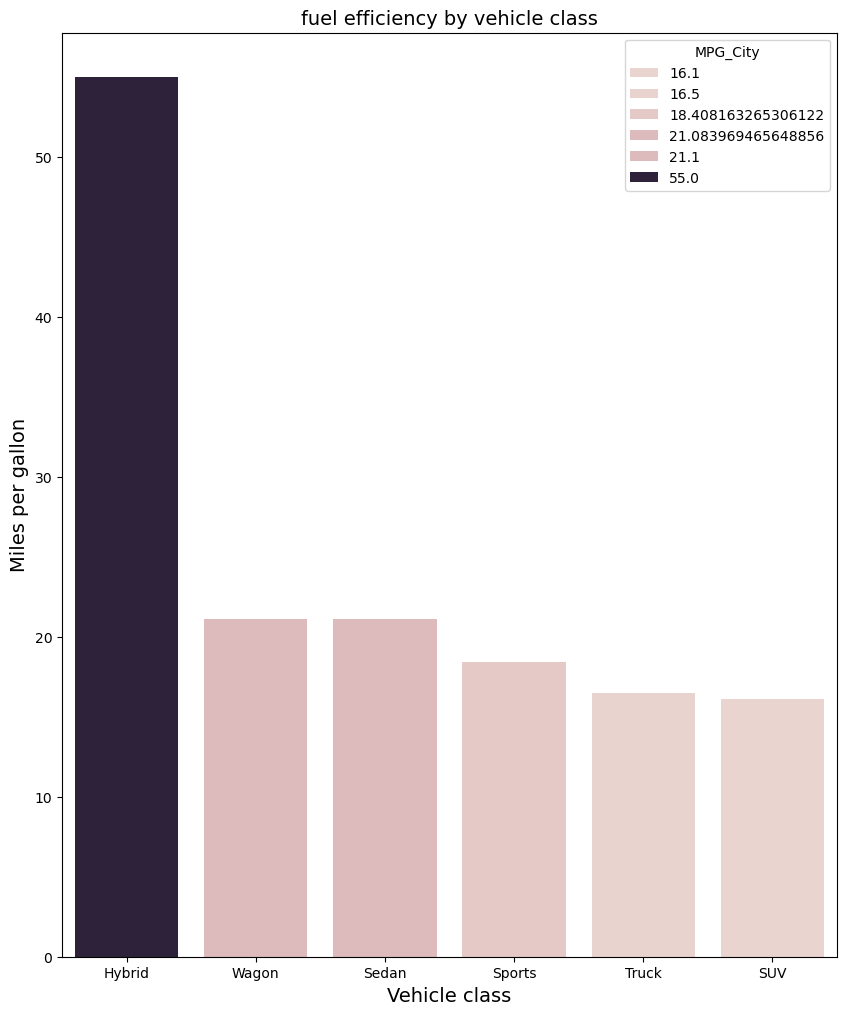

In [267]:
plt.figure(figsize= (10, 12))
sns.barplot(data = MPG_mean_sort, x = MPG_mean_sort['VehicleClass'], y = MPG_mean_sort['MPG_City'],  hue = MPG_mean_sort['MPG_City'])
plt.xlabel('Vehicle class', size = 14)
plt.ylabel('Miles per gallon', size = 14)
plt.title('fuel efficiency by vehicle class', size = 14)
plt.show()

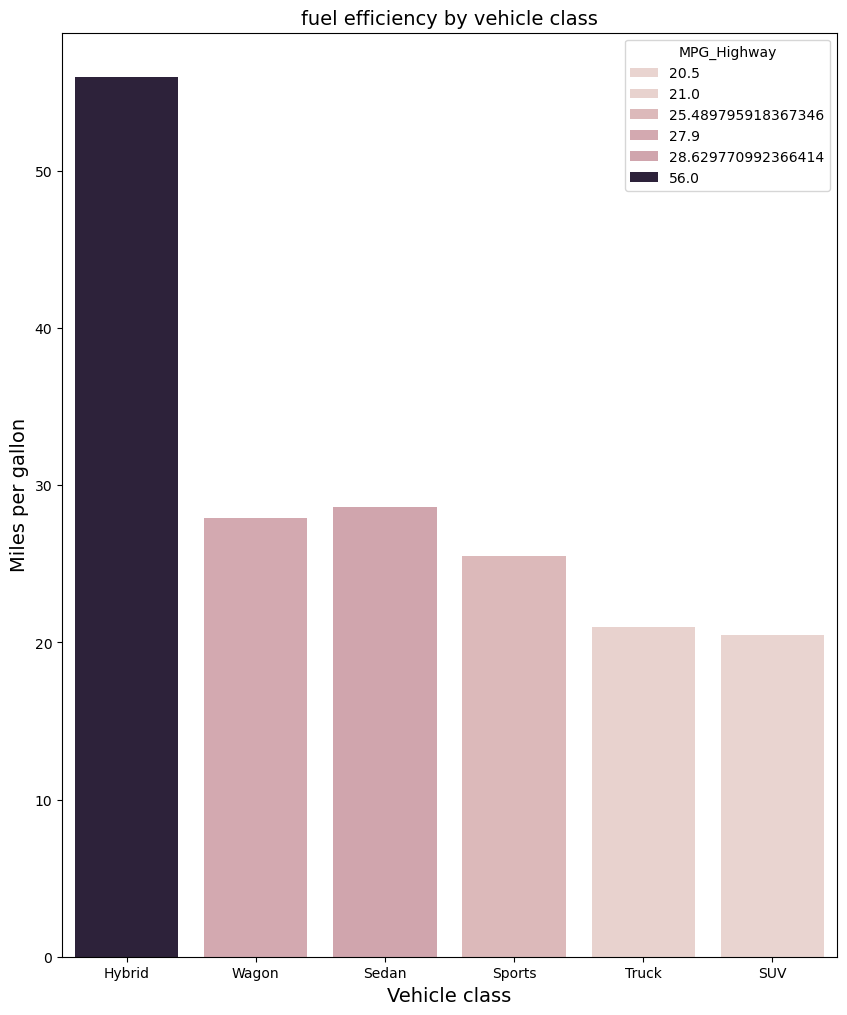

In [269]:
plt.figure(figsize= (10, 12))
sns.barplot(data = MPG_mean_sort, x = MPG_mean_sort['VehicleClass'], y = MPG_mean_sort['MPG_Highway'],  hue = MPG_mean_sort['MPG_Highway'])
plt.xlabel('Vehicle class', size = 14)
plt.ylabel('Miles per gallon', size = 14)
plt.title('fuel efficiency by vehicle class', size = 14)
plt.show()

## Conclusions:
- Hybrid vehicles are by far the most fuel-efficient, averaging 55 MPG in the city and 56 MPG on the highway, making them ideal for fuel economy and eco-conscious drivers.
- Wagons and sedans follow with relatively high fuel efficiency among conventional vehicles, averaging around 21 MPG (city) and 27–28 MPG (highway).
- Sports cars have moderate efficiency, which may be surprising given their performance orientation — about 18.4 MPG (city) and 25.5 MPG (highway).
- Trucks and SUVs are the least fuel-efficient, with trucks averaging 16.5 MPG (city) and SUVs at 16.1 MPG (city). Their lower MPG is expected due to their larger size and intended use.

## Goal 5: What is the lightest vehicle class?

In [275]:
df

,Brand,VehicleClass,Region,MSRP,DealerCost,EngineSize,HorsePower,MPG_City,MPG_Highway,Weight,Wheelbase,Length,Value
0,Acura,SUV,Asia,36945,33337,3.5,265,17,23,4451,106,189,3608
1,Acura,Sedan,Asia,23820,21761,2.0,200,24,31,2778,101,172,2059
2,Acura,Sedan,Asia,26990,24647,2.4,200,22,29,3230,105,183,2343
3,Acura,Sedan,Asia,33195,30299,3.2,270,20,28,3575,108,186,2896
4,Acura,Sedan,Asia,43755,39014,3.5,225,18,24,3880,115,197,4741
...,...,...,...,...,...,...,...,...,...,...,...,...,...
423,Volvo,Sedan,Europe,40565,38203,2.4,197,21,28,3450,105,186,2362
424,Volvo,Sedan,Europe,42565,40083,2.3,242,20,26,3450,105,186,2482
425,Volvo,Sedan,Europe,45210,42573,2.9,268,19,26,3653,110,190,2637
426,Volvo,Wagon,Europe,26135,24641,1.9,170,22,29,2822,101,180,1494


## 1) Total size

In [285]:
Size = df.groupby('VehicleClass')[['Weight','Length','Wheelbase']].sum().reset_index()

In [287]:
Size

,VehicleClass,Weight,Length,Wheelbase
0,Hybrid,7472,505,304
1,SUV,266666,11288,6665
2,Sedan,890555,49021,28296
3,Sports,161489,8491,4899
4,Truck,102018,4985,2952
5,Wagon,103164,5473,3174


In [301]:
Size_sort = Size.sort_values(by = ['Weight', 'Length', 'Wheelbase'], ascending = False)

In [303]:
Size_sort

,VehicleClass,Weight,Length,Wheelbase
2,Sedan,890555,49021,28296
1,SUV,266666,11288,6665
3,Sports,161489,8491,4899
5,Wagon,103164,5473,3174
4,Truck,102018,4985,2952
0,Hybrid,7472,505,304


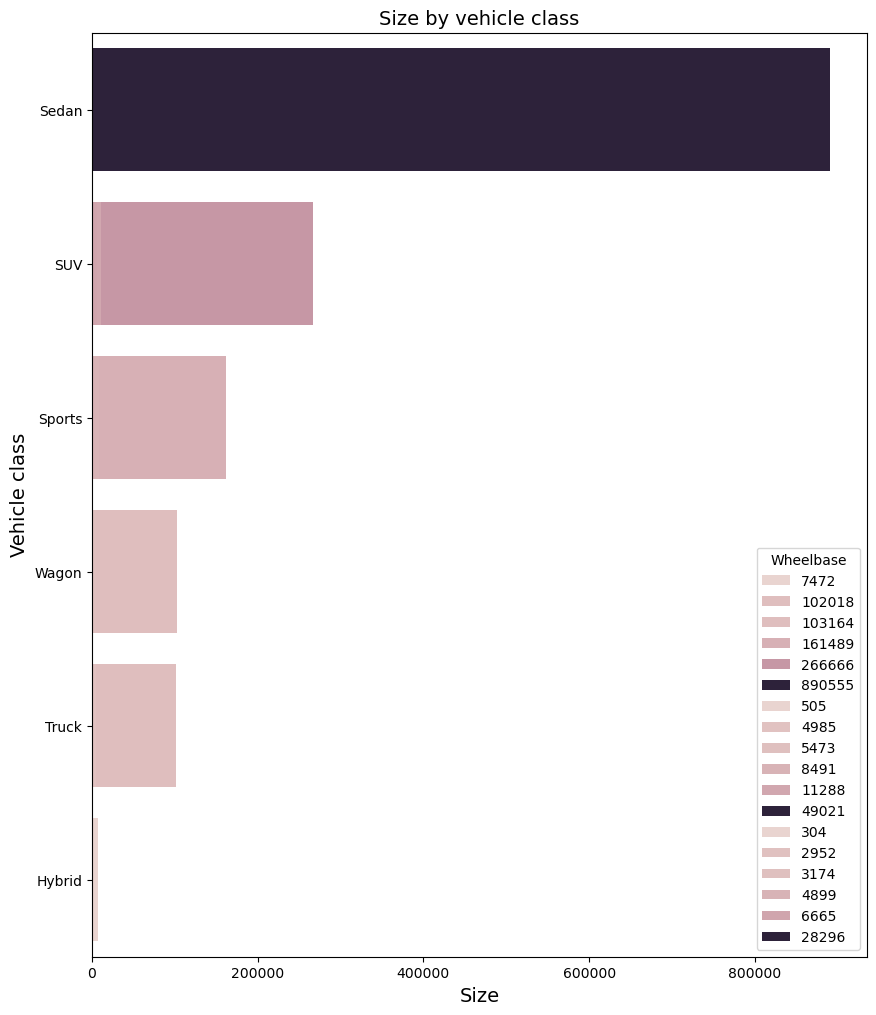

In [307]:
plt.figure(figsize= (10, 12))
sns.barplot(data = Size_sort, x = Size_sort['Weight'], y = Size_sort['VehicleClass'],  hue = Size_sort['Weight'])
sns.barplot(data = Size_sort, x = Size_sort['Length'], y = Size_sort['VehicleClass'],  hue = Size_sort['Length'])
sns.barplot(data = Size_sort, x = Size_sort['Wheelbase'], y = Size_sort['VehicleClass'],  hue = Size_sort['Wheelbase'])
plt.xlabel('Size', size = 14)
plt.ylabel('Vehicle class', size = 14)
plt.title('Size by vehicle class', size = 14)
plt.show()

## Conclusions:
- Sedan vehicle class is the heaviest and longest vehicle class, this suggests that sedans are both widely produced and used among families and middle class consumers.
- Followed by SUVS, they are large and robust ,their size contributes to their wide usage in everything from work based to travel to comfort, however they are less heavy than sedans.
- Sports are less heavy and lighter, this class's light vehicle size contributes to its accelerarion and speed, which is associated with 'cool' vibes.
- Wagons, Trucks are less heavy, due to them being function based.
- Hybrid is the lightest vehicle class, due to them being made specificaly to be environmental-friendly, which results to be being made lighter.

## 2) Effective size

In [311]:
Effect_size = df.groupby('VehicleClass')[['Weight','Length','Wheelbase']].mean().reset_index()

In [313]:
Effect_size

,VehicleClass,Weight,Length,Wheelbase
0,Hybrid,2490.666667,168.333333,101.333333
1,SUV,4444.433333,188.133333,111.083333
2,Sedan,3399.064885,187.103053,108.000000
3,Sports,3295.693878,173.285714,99.979592
4,Truck,4250.750000,207.708333,123.000000
5,Wagon,3438.800000,182.433333,105.800000


In [315]:
Effect_size_sort = Effect_size.sort_values(by = ['Weight', 'Length', 'Wheelbase'], ascending = False)

In [317]:
Effect_size_sort

,VehicleClass,Weight,Length,Wheelbase
1,SUV,4444.433333,188.133333,111.083333
4,Truck,4250.750000,207.708333,123.000000
5,Wagon,3438.800000,182.433333,105.800000
2,Sedan,3399.064885,187.103053,108.000000
3,Sports,3295.693878,173.285714,99.979592
0,Hybrid,2490.666667,168.333333,101.333333


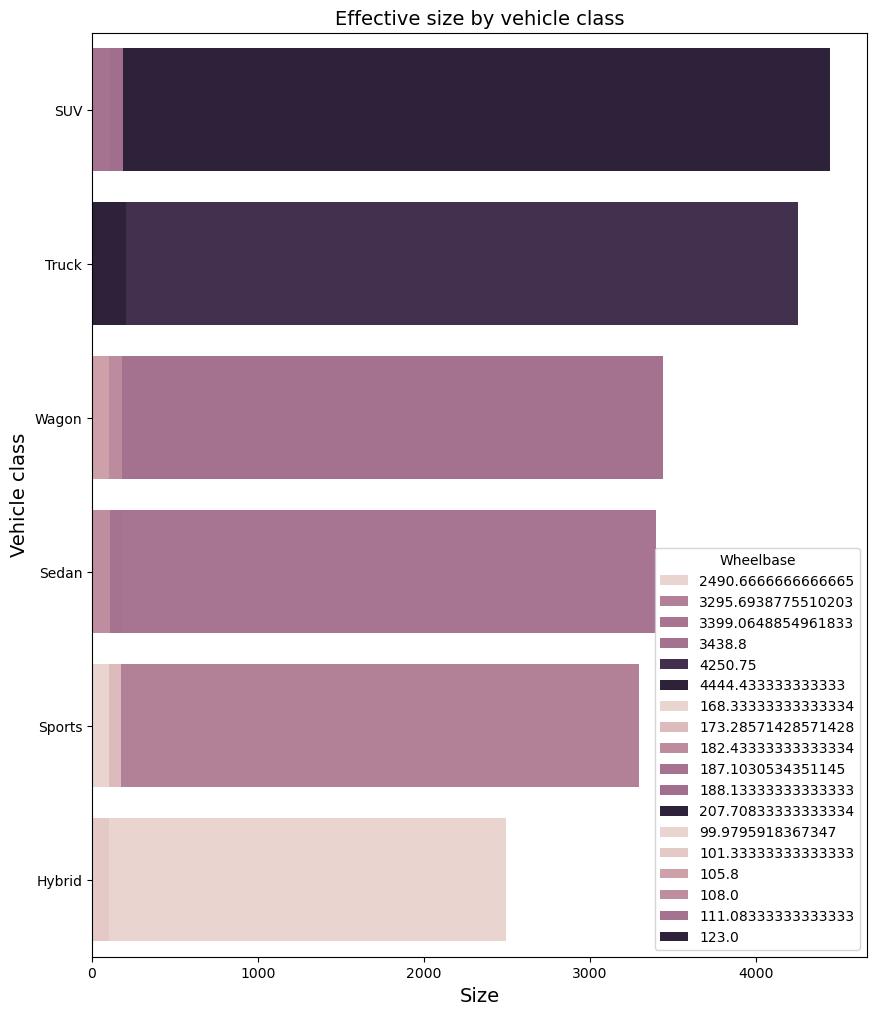

In [320]:
plt.figure(figsize= (10, 12))
sns.barplot(data = Effect_size_sort, x = Effect_size_sort['Weight'], y = Effect_size_sort['VehicleClass'],  hue = Effect_size_sort['Weight'])
sns.barplot(data = Size_sort, x = Effect_size_sort['Length'], y = Effect_size_sort['VehicleClass'],  hue = Effect_size_sort['Length'])
sns.barplot(data = Size_sort, x = Effect_size_sort['Wheelbase'], y = Effect_size_sort['VehicleClass'],  hue = Effect_size_sort['Wheelbase'])
plt.xlabel('Size', size = 14)
plt.ylabel('Vehicle class', size = 14)
plt.title('Effective size by vehicle class', size = 14)
plt.show()

## Conclusions:
- SUVS and Trucks vehicle classes are the heaviest in terms of size.
## For SUVS:
- This vehicle class is widely used for lots of activities: From travelling to work to comfort to carrying equipment and supplies.
## For Trucks:
- This vehicle class is work-based, it is used for carrying cargo: From cars to merchandises to gasoline to fuel.
- Wagons and sedans are lighter.
## For wagons:
- Wagons vehicle class is a historically-important vehicle class due to it being the first wheel based vehicle invented: It served in Ancient civilizations (Egypt, Persia, Babylon, Greece, Rome), medieval period, Age of discovery, American expansion to the west, Industrial revolution, and so on.
- Nowadays, Wagons are used in farms.
## For Sedans:
- Sedans are widely used by the middle class due to it being practical for every situation: from travelling to commuting.
- Sports class is lighter.
## For sports:
- Vehicles belonging to this class are made for one thing: luxury, and luxury is expressed in performance and speed.
- Hybrid is the lightest vehicle.
## For Hybrid:
- This class's lighter size contributes to the world tendency to make more environment friendly products.

## Goal 6: Which vehicle class that has the best performance?